# KCB 데이터 유형·결측·시간 변수 진단

이 노트북은 `preprocess/`의 분석 도구입니다. 원본 CSV는 저장소 최상위에 두고, 모든 열을 먼저 문자열로 읽어 **저장 형식**과 **모델에 전달할 기본 유형**을 분리합니다. 청크 단위의 전체 파일 분석은 `audit.py`가 수행합니다.

전체 실행 시 `preprocess/`에 `feature_types.csv` (`variable,type`)와 `type_experiments.md`를 생성합니다. 기본 유형은 `boolean`, `categorical`, `numeric`, `month_index`, `target`, `unknown`입니다. 유형은 현재 관측 자료에서 적용한 **기본 규칙**이지 업무상 의미의 확정이 아닙니다. 비교가 필요한 변수와 대안은 Markdown 문서에 기록됩니다.

관측 CSV는 202306–202405, 최종 평가 기간은 202406–202411입니다. 미래 6개월의 정답은 이 CSV에 없으므로 최종 성능은 여기서 계산할 수 없습니다. 원본 CSV는 수정하지 않습니다. 저장소 루트에서 `jupyter lab preprocess/data_audit.ipynb`를 열고 위에서부터 실행합니다.

## 1. 행별 가중 오분류율과 누수 방지

각 행의 오분류값(오분류 1, 정분류 0)에 월별 가중치를 먼저 곱하고 **모든 평가 행의 개수**로 나눕니다.

`weighted_error = sum(weight_i * (prediction_i != target_i)) / N`

가중치는 첫 2개월 `0.1`, 다음 2개월 `0.3`, 마지막 2개월 `0.6`입니다. 2개월별 오분류율을 구한 뒤 합산하거나, 가중치 합으로 나누지 않습니다. 과거 역검증에는 `202306–202310 → 202311–202404`, `202306–202311 → 202312–202405`를 사용합니다.

모델·분류 임계값·범주 사전·대체값·스케일러와 유형 선택은 각 창의 **학습 기간에서만** 결정합니다. 전체 기간 분포는 기술통계입니다. `TARGET`의 관측 시점과 `TS_*` 파생 열의 생성 시점이 확인되기 전에는 누수 가능성을 배제할 수 없습니다. 평가 데이터의 실제 언더샘플 비율도 확보 후 확인해야 합니다.

In [1]:
from decimal import Decimal
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

MODULE_DIR = Path.cwd() if Path.cwd().name == "preprocess" else Path.cwd() / "preprocess"
sys.path.insert(0, str(MODULE_DIR))
from audit import (
    BLOCK_WEIGHTS, FIRST_MONTH, FUTURE_END, FUTURE_START, backtest_windows,
    data_path, month_after, month_index, profile_dataset,
    weighted_misclassification, write_type_artifacts,
)

CSV_PATH = data_path()
CHUNK_SIZE = 10_000
MAX_ROWS = None  # 빠른 탐색에만 정수를 사용. 최종 판단은 None으로 전체 검사.
SAMPLE_PER_CHUNK = 100
SEED = 42
CARDINALITY_CAP = 1000  # 이 수를 넘으면 정확한 종류 수 대신 하한을 기록.

print("source:", CSV_PATH)
print("source size (MiB):", round(CSV_PATH.stat().st_size / 2**20, 1))
print("future months:", [month_after(FUTURE_START, i) for i in range(6)])

source: C:\Users\jonghyeon\Documents\higher_analysis\data_analysis_project_1st\kcb_202306_202405_undersampled_1to4.csv
source size (MiB): 302.1
future months: ['202406', '202407', '202408', '202409', '202410', '202411']


## 2. 전체 열의 원본 표현과 기본 유형

`numeric_parse_rate`가 1이어도 수치형으로 확정하지 않습니다. `Y/N`은 불리언, `Y/N/P`는 세 범주의 범주형입니다. 숫자 0/1도 우선 불리언입니다. 그 밖에 **정수 고유값이 2~20개이고 정렬된 인접 값의 차이가 모두 동일하거나, 정수 고유값이 정확히 3개인 경우** 기본 범주형으로 기록합니다. 시작값은 0, 1 또는 다른 정수여도 되고, 간격도 1일 필요가 없습니다. 고유값이 4~20개이고 다른 간격이 하나라도 있으면 위치에 관계없이 기본 수치형으로 둡니다. 간격 예외를 특수값이나 결측으로 자동 해석하지 않습니다. 이 패턴은 횟수·점수에서도 나타날 수 있어 수치형과 비교해야 합니다.

문자열 고유값은 1000개까지 정확히 추적합니다. `distinct_capped=True`인 열은 모든 수준의 간격을 확정할 수 없으므로 기본 수치형과 추가 검토 대상으로 둡니다. `sentinel_like_8_9_n`은 특수값 의심 건수일 뿐 자동으로 결측으로 바꾸지 않습니다. 0도 일괄 결측 처리하지 않습니다.

In [2]:
audit = profile_dataset(
    CSV_PATH, chunksize=CHUNK_SIZE, max_rows=MAX_ROWS,
    sample_per_chunk=SAMPLE_PER_CHUNK, seed=SEED,
    cardinality_cap=CARDINALITY_CAP, supervised_train_end="202311",
)
features = audit.features.set_index("column", drop=False)
rows = audit.rows.copy()
print(f"rows={audit.total_rows:,}; columns={len(features):,}; sampled_rows={len(audit.sample):,}")
display(features["candidate_type"].value_counts().rename_axis("candidate_type").to_frame("n_columns"))
display(features.sort_values("missing_pct", ascending=False)[
    ["candidate_type", "missing_n", "missing_pct", "distinct_at_least", "numeric_parse_rate", "review"]
].head(25))
if MAX_ROWS is None:
    schema_path, notes_path = write_type_artifacts(audit, CSV_PATH.parent)
    print('type map:', schema_path)
    print('comparison notes:', notes_path)
else:
    print('Partial sample: type files were not overwritten.')
print('baseline types:')
display(features.base_type.value_counts().rename_axis('type').to_frame('n_columns'))

rows=162,355; columns=560; sampled_rows=1,700


,n_columns
candidate_type,
integer_category_or_count,177
integer_numeric_or_identifier,142
binary,106
continuous_candidate,84
integer_code_or_ordered,35
constant,10
categorical_or_mixed,4
calendar_month,1
target,1


,candidate_type,missing_n,missing_pct,distinct_at_least,numeric_parse_rate,review
column,,,,,,
AS1C30103,integer_numeric_or_identifier,161655,0.995688,124,1.0,check ID/date/sentinel patterns and meaning
DA1000104,integer_numeric_or_identifier,160784,0.990324,648,1.0,check ID/date/sentinel patterns and meaning
ASCD30135,integer_numeric_or_identifier,159678,0.983511,1001,1.0,check ID/date/sentinel patterns and meaning
AS1C30104,integer_numeric_or_identifier,159479,0.982286,256,1.0,check ID/date/sentinel patterns and meaning
D2Z000078,integer_numeric_or_identifier,159207,0.980610,1001,1.0,check ID/date/sentinel patterns and meaning
D2Z000072,integer_numeric_or_identifier,159204,0.980592,1001,1.0,check ID/date/sentinel patterns and meaning
D2Z000071,integer_numeric_or_identifier,159204,0.980592,1001,1.0,check ID/date/sentinel patterns and meaning
D10187D00,integer_numeric_or_identifier,152452,0.939004,1001,1.0,check ID/date/sentinel patterns and meaning
ASCD30137,integer_numeric_or_identifier,152404,0.938708,1001,1.0,check ID/date/sentinel patterns and meaning


type map: C:\Users\jonghyeon\Documents\higher_analysis\data_analysis_project_1st\preprocess\feature_types.csv
comparison notes: C:\Users\jonghyeon\Documents\higher_analysis\data_analysis_project_1st\preprocess\type_experiments.md
baseline types:


,n_columns
type,
numeric,293
categorical,148
boolean,117
month_index,1
target,1


In [3]:
def inspect_feature(name: str, top_values: int = 15):
    # 한 열의 전체 요약과 표본의 원본 토큰 빈도를 확인합니다.
    if name not in features.index:
        raise KeyError(name)
    display(features.loc[[name]].T.rename(columns={name: "value"}))
    print("sample raw-token frequencies (not full-data frequencies)")
    display(audit.sample[name].value_counts(dropna=False).head(top_values).to_frame("sample_n"))

inspect_feature("LNMON")

column,value
column,LNMON
candidate_type,calendar_month
review,parse YYYYMM; compare month index with no-time...
base_type,month_index
type_reason,convert YYYYMM to one-based consecutive months
one_based_contiguous,None
zero_based_contiguous,None
integer_level_coverage,NaN
integer_step,NaN
integer_level_count,12.0


sample raw-token frequencies (not full-data frequencies)


,sample_n
LNMON,
202404,164
202307,162
202308,151
202401,151
202312,150
202306,150
202403,147
202310,142
202405,140


## 3. 숫자로 저장된 코드와 문자열 불리언

`candidate_type`은 종전의 탐색용 분류이고, `preprocess/feature_types.csv`에 내보내는 유형은 `base_type`입니다. `binary` 판정은 숫자로 읽은 값의 집합이 `{0,1}`에 속하는지 확인합니다. 문자열은 전체 관측값이 정확히 `Y/N`이면 `boolean`, `Y/N/P`이면 `categorical`로 기록합니다. `P`의 뜻을 모르므로 세 번째 수준으로 유지합니다.

정수는 `2~20개 수준 + 모든 인접 간격 동일`이면 기본 `categorical`입니다. `정확히 3개 수준`인 정수도 간격과 관계없이 기본 `categorical`입니다. 고유값이 4~20개인 정수에서 다른 간격이 하나라도 있으면 끝이든 내부든 기본 `numeric`입니다. 두 수준의 차이도 일정 간격으로 인정하지만 `0/1`은 앞선 불리언 규칙이 우선합니다. 세 수준은 두 인접 간격이 서로 달라도 예외 1개로 이 기준에 들어갑니다. 이 기준에 맞지 않는 정수는 우선 `numeric`으로 두고 범주 코드 가능성을 비교 실험 문서에 남깁니다. `integer_gap_exception_location`과 `integer_gap_exception_between`은 진단 정보입니다. 예외 위치를 범주형 분류의 근거로 사용하거나 해당 값을 결측으로 확정하지 않습니다. `leading_zero_n`은 `001` 같은 원본 문자열만 감지합니다.

In [4]:
type_columns = ["candidate_type", "missing_pct", "distinct_at_least", "distinct_capped",
                "numeric_parse_rate", "integer_rate_of_numeric", "numeric_min", "numeric_max", "review"]
for kind in ["binary", "integer_category_or_count", "integer_code_or_ordered",
             "integer_numeric_or_identifier", "categorical_or_mixed"]:
    selected = features.loc[features.candidate_type.eq(kind), type_columns]
    print(f"{kind}: {len(selected)} columns")
    display(selected.head(20))

# 6/8자리 숫자 토큰은 연월/일자일 수도 있지만, 단순 코드일 수도 있습니다.
date_like = []
for name in features.index.drop(["LNMON", "TARGET"]):
    values = audit.sample[name]
    observed = values[~values.str.upper().isin({"", "NA", "N/A", "NAN", "NULL", "NONE", "<NA>"})]
    if len(observed) and observed.str.fullmatch(r"\d{6}|\d{8}").mean() >= 0.95:
        date_like.append(name)
print("6/8-digit date-or-code candidates:", date_like[:50], "(total:", len(date_like), ")")
print("leading-zero integer tokens (possible code/identifier):")
display(features.loc[features.leading_zero_n.gt(0),
    ["candidate_type", "leading_zero_n", "distinct_at_least", "review"]]
    .sort_values("leading_zero_n", ascending=False).head(30))
print('String boolean/category examples and their baseline types:')
display(features.loc[['AS1C10148', 'SS1200000', 'TS_VOLATILITY_APS001_FLIPS', 'TS_MOMENTUM_APS001_STATE'],
    ['base_type', 'type_reason', 'distinct_at_least']])
# 전체 데이터에서 확인된 범주형 변수를 생략 없이 표시합니다.
def observed_levels(name: str) -> str:
    values = audit.distinct_values[name]
    if values is None:
        return f">{CARDINALITY_CAP} levels; exact list unavailable"
    if pd.notna(features.at[name, 'integer_step']):
        return ', '.join(map(str, sorted({int(Decimal(value)) for value in values})))
    return ', '.join(sorted(values))

detail_columns = [
    'candidate_type', 'type_reason', 'distinct_at_least', 'integer_level_count', 'missing_pct',
    'numeric_min', 'numeric_max', 'integer_step', 'integer_gap_exceptions',
    'integer_gap_exception_location', 'integer_gap_exception_between',
]
categorical_detail = features.loc[features.base_type.eq('categorical'), detail_columns].copy()
categorical_detail.insert(1, 'observed_levels', [observed_levels(name) for name in categorical_detail.index])
print(f'All default categorical variables: {len(categorical_detail)} (all rows shown below)')
display(HTML(categorical_detail.to_html(max_rows=None, max_cols=None, escape=True)))

nonuniform_numeric = features.loc[
    features.base_type.eq('numeric') & features.integer_level_count.between(4, 20) &
    features.integer_gap_exceptions.gt(0), detail_columns
].copy()
nonuniform_numeric.insert(1, 'observed_levels', [observed_levels(name) for name in nonuniform_numeric.index])
print(f'Numeric with unequal adjacent gaps (4-20 levels): {len(nonuniform_numeric)}')
display(HTML(nonuniform_numeric.to_html(max_rows=None, max_cols=None, escape=True)))

three_level_exception = categorical_detail.loc[
    categorical_detail.integer_level_count.eq(3) &
    categorical_detail.integer_gap_exceptions.gt(0)
]
print(f'Categorical under the three-integer-level exception: {len(three_level_exception)}')
display(HTML(three_level_exception.to_html(max_rows=None, max_cols=None, escape=True)))
print('Y/N input example:')
print(audit.sample['AS1C10148'].map({'Y': True, 'N': False}).astype('boolean').dtype)
print('Y/N/P input example:')
print(pd.Categorical(audit.sample['SS1200000'], categories=['N', 'Y', 'P']).dtype)

binary: 106 columns


,candidate_type,missing_pct,distinct_at_least,distinct_capped,numeric_parse_rate,integer_rate_of_numeric,numeric_min,numeric_max,review
column,,,,,,,,,
AS1C10132,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
AS1C1G157,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
DA0D00019,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
DD0210X13,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
DD0210X16,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
DD0211X10,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
DDC001001,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
D32000001,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...
D3011000K,binary,0.0,2,False,1.0,1.0,0.0,1.0,use as a binary feature; expose as categorical...


integer_category_or_count: 177 columns


,candidate_type,missing_pct,distinct_at_least,distinct_capped,numeric_parse_rate,integer_rate_of_numeric,numeric_min,numeric_max,review
column,,,,,,,,,
U84010100,integer_category_or_count,0.000203,20,False,1.0,1.0,1.0,20.0,verify code versus ordered count using data di...
UR1101100,integer_category_or_count,0.000000,19,False,1.0,1.0,2.0,20.0,verify code versus ordered count using data di...
AL012G003,integer_category_or_count,0.000148,5,False,1.0,1.0,1.0,5.0,verify code versus ordered count using data di...
AL012G004,integer_category_or_count,0.000148,6,False,1.0,1.0,1.0,6.0,verify code versus ordered count using data di...
AL012G005,integer_category_or_count,0.000148,7,False,1.0,1.0,1.0,7.0,verify code versus ordered count using data di...
AL012G009,integer_category_or_count,0.000148,4,False,1.0,1.0,1.0,4.0,verify code versus ordered count using data di...
AL012G010,integer_category_or_count,0.000148,4,False,1.0,1.0,1.0,4.0,verify code versus ordered count using data di...
AL012G011,integer_category_or_count,0.000148,5,False,1.0,1.0,1.0,5.0,verify code versus ordered count using data di...
AL012G013,integer_category_or_count,0.000148,5,False,1.0,1.0,1.0,5.0,verify code versus ordered count using data di...


integer_code_or_ordered: 35 columns


...

Numeric with unequal adjacent gaps (4-20 levels): 31


,candidate_type,observed_levels,type_reason,distinct_at_least,integer_level_count,missing_pct,numeric_min,numeric_max,integer_step,integer_gap_exceptions,integer_gap_exception_location,integer_gap_exception_between
column,,,,,,,,,,,,
AS1C20112,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 13",unequal adjacent integer gaps; use numeric baseline and compare category encoding,12,12.0,0.0,0.0,13.0,1.0,2.0,multiple,None
AS1C20113,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 21",unequal adjacent integer gaps; use numeric baseline and compare category encoding,20,20.0,0.0,0.0,21.0,1.0,2.0,multiple,None
AS1C20114,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14",unequal adjacent integer gaps; use numeric baseline and compare category encoding,14,14.0,0.0,0.0,14.0,1.0,1.0,internal,10→12
AS1C20120,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15",unequal adjacent integer gaps; use numeric baseline and compare category encoding,15,15.0,0.0,0.0,15.0,1.0,1.0,internal,10→12
ASCD20134,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 10, 11",unequal adjacent integer gaps; use numeric baseline and compare category encoding,10,10.0,0.0,0.0,11.0,1.0,1.0,internal,7→10
ASCD20136,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13",unequal adjacent integer gaps; use numeric baseline and compare category encoding,13,13.0,0.0,0.0,13.0,1.0,1.0,upper_edge,11→13
D10110D0K,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13",unequal adjacent integer gaps; use numeric baseline and compare category encoding,12,12.0,0.0,0.0,13.0,1.0,1.0,upper_edge,10→13
D10110D0N,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17",unequal adjacent integer gaps; use numeric baseline and compare category encoding,17,17.0,0.0,0.0,17.0,1.0,1.0,internal,14→16
D10120D0T,integer_category_or_count,"0, 1, 2, 3, 4, 5, 6, 7, 8, 10",unequal adjacent integer gaps; use numeric baseline and compare category encoding,10,10.0,0.0,0.0,10.0,1.0,1.0,upper_edge,8→10


Categorical under the three-integer-level exception: 1


,candidate_type,observed_levels,type_reason,distinct_at_least,integer_level_count,missing_pct,numeric_min,numeric_max,integer_step,integer_gap_exceptions,integer_gap_exception_location,integer_gap_exception_between
column,,,,,,,,,,,,
DD0140X1C,integer_category_or_count,"0, 37, 69",three observed integer levels; categorical baseline regardless of spacing,3,3.0,0.0,0.0,69.0,32.0,1.0,lower_edge,0→37


Y/N input example:
boolean
Y/N/P input example:
category


## 4. LNMON의 연속 월 인덱스

`YYYYMM` 정수의 차이는 월 차이가 아닙니다. 아래에서 `202312 → 202401`은 원본 숫자 차이가 89, 월 인덱스 차이는 1임을 검증합니다. 따라서 **표현 변환 자체는 타당**합니다. 다만 인덱스를 넣었을 때 오분류율이 좋아지는지는 이후 모델별 역검증 문제입니다. 트리 모델은 학습 범위 밖의 13–18에 대해 월 숫자만으로 시간 추세를 외삽하지 못할 수 있습니다. 연월 one-hot도 학습 중 없던 미래 6개월을 직접 표현하지 못합니다. 월별/계절성 파생 변수는 관측 기간이 12개월뿐이므로 근거가 제한적입니다.

,n_rows,positives,mean_missing,target_rate,month_index
LNMON,,,,,
202306,14252,2837,28.295116,0.199060,1
202307,13669,2781,28.448241,0.203453,2
202308,13757,2553,28.482300,0.185578,3
202309,13137,2454,28.278070,0.186801,4
202310,14057,2705,28.411894,0.192431,5
202311,12031,2130,28.711828,0.177043,6
202312,13513,2553,28.360246,0.188929,7
202401,13707,2716,28.179762,0.198147,8
202402,12460,2569,28.470465,0.206180,9


,LNMON,month_index,period
0,202306,1,observed
1,202307,2,observed
2,202308,3,observed
3,202309,4,observed
4,202310,5,observed
5,202311,6,observed
6,202312,7,observed
7,202401,8,observed
8,202402,9,observed
9,202403,10,observed


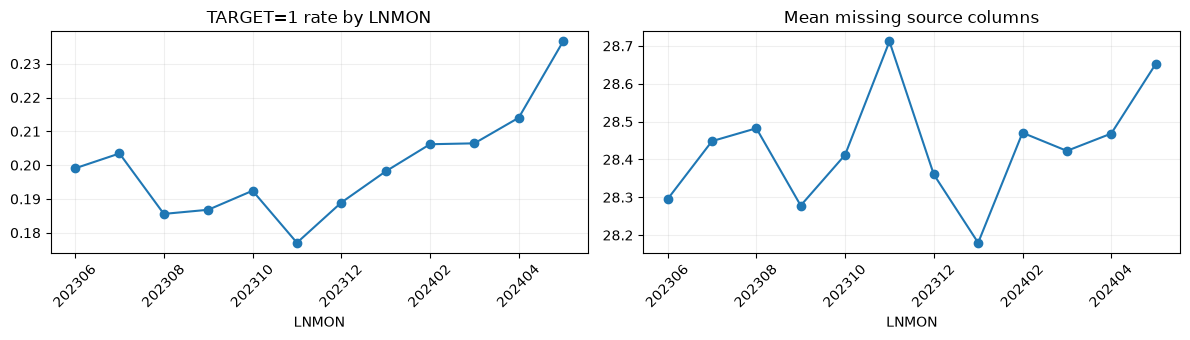

In [5]:
assert month_index("202306") == 1
assert month_index("202405") == 12
assert month_index("202406") == 13
assert month_index("202411") == 18
assert int("202401") - int("202312") == 89
assert month_index("202401") - month_index("202312") == 1

month_table = (rows.groupby("LNMON", sort=True)
               .agg(n_rows=("TARGET", "size"), positives=("TARGET", "sum"),
                    mean_missing=("missing_count", "mean")))
month_table["target_rate"] = month_table.positives / month_table.n_rows
month_table["month_index"] = [month_index(x) for x in month_table.index]
display(month_table)
display(pd.DataFrame({
    "LNMON": [month_after(FIRST_MONTH, i) for i in range(18)],
    "month_index": list(range(1, 19)),
    "period": ["observed"] * 12 + ["future evaluation"] * 6,
}))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
month_table.target_rate.plot(ax=axes[0], marker="o", title="TARGET=1 rate by LNMON")
month_table.mean_missing.plot(ax=axes[1], marker="o", title="Mean missing source columns")
for axis in axes:
    axis.tick_params(axis="x", rotation=45)
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. 결측 개수, missing indicator, 특수값 플래그

행별 결측 개수에는 `_SV_FLAG_`를 제외한 원본 설명변수만 포함합니다. 아래 표의 `TARGET` 관계는 역검증을 위해 분리한 **202306–202311 학습 기간만** 사용합니다. 결측률이 높은 열을 일괄 제거하지 않고, 남아 있는 값의 규모·월별 안정성·결측 indicator의 신호를 함께 봅니다. `train_target_rate_gap`은 인과 효과가 아니며 작은 집단에서는 불안정합니다.

In [6]:
train_rows = rows.loc[rows.LNMON.le("202311")].copy()
cuts = [-1, 0, 5, 10, 20, 50, 100, 200, 560]
train_rows["missing_bin"] = pd.cut(train_rows.missing_count, bins=cuts)
display(train_rows.groupby("missing_bin", observed=True)
        .agg(n_rows=("TARGET", "size"), target_rate=("TARGET", "mean"),
             min_missing=("missing_count", "min"), max_missing=("missing_count", "max")))

indicator_candidates = features.loc[
    features.train_missing_n.ge(100) &
    features.train_missing_n.le(len(train_rows) - 100) &
    ~features.index.isin(["TARGET", "LNMON"]),
    ["candidate_type", "missing_pct", "train_missing_n", "train_missing_target_rate",
     "train_observed_target_rate", "train_target_rate_gap"]
].copy()
indicator_candidates["abs_gap"] = indicator_candidates.train_target_rate_gap.abs()
display(indicator_candidates.sort_values("abs_gap", ascending=False).head(30))
print("This ranks candidates for a later ablation; it does not select features automatically.")

,n_rows,target_rate,min_missing,max_missing
missing_bin,,,,
"(0, 5]",5,1.000000,2,5
"(5, 10]",874,0.267735,6,10
"(10, 20]",21364,0.141172,11,20
"(20, 50]",48333,0.210995,21,50
"(50, 100]",10327,0.194345,51,75


,candidate_type,missing_pct,train_missing_n,train_missing_target_rate,train_observed_target_rate,train_target_rate_gap,abs_gap
column,,,,,,,
DA1000104,integer_numeric_or_identifier,0.990324,80058,0.187701,0.512426,-0.324725,0.324725
D2Z000078,integer_numeric_or_identifier,0.980610,79252,0.186166,0.427620,-0.241454,0.241454
D2Z000072,integer_numeric_or_identifier,0.980592,79251,0.186168,0.427361,-0.241193,0.241193
D2Z000071,integer_numeric_or_identifier,0.980592,79251,0.186168,0.427361,-0.241193,0.241193
DUN000028,integer_numeric_or_identifier,0.934114,74806,0.180066,0.326390,-0.146324,0.146324
UA1040003,integer_numeric_or_identifier,0.830267,67091,0.168607,0.300319,-0.131712,0.131712
D10187D00,integer_numeric_or_identifier,0.939004,75233,0.182513,0.304938,-0.122425,0.122425
C1Z001474,continuous_candidate,0.001497,134,0.291045,0.190927,0.100118,0.100118
UA1040000,integer_numeric_or_identifier,0.718105,58207,0.164396,0.259561,-0.095165,0.095165


This ranks candidates for a later ablation; it does not select features automatically.


In [7]:
display(features.loc[features.sentinel_like_8_9_n.gt(0),
    ["candidate_type", "sentinel_like_8_9_n", "missing_n", "review"]]
    .sort_values("sentinel_like_8_9_n", ascending=False).head(30))
print("flag/source missingness agreement")
display(audit.flags.sort_values(["flag_only", "missing_only"], ascending=False).head(30))
print("Example: inspect a source and its flag side by side")
example = "C1L120066"
display(features.loc[[example, example + "_SV_FLAG_8888888_8"],
    ["candidate_type", "missing_n", "distinct_at_least", "review"]])

,candidate_type,sentinel_like_8_9_n,missing_n,review
column,,,,
C1Z000953,integer_numeric_or_identifier,1149,0,check ID/date/sentinel patterns and meaning
UR1102100,integer_numeric_or_identifier,1140,0,check ID/date/sentinel patterns and meaning
C1N295W03,integer_numeric_or_identifier,1099,0,check ID/date/sentinel patterns and meaning
C1Z000954,integer_numeric_or_identifier,1045,0,check ID/date/sentinel patterns and meaning
C1Z000816,integer_numeric_or_identifier,796,0,check ID/date/sentinel patterns and meaning
L2Z001295,integer_numeric_or_identifier,724,0,check ID/date/sentinel patterns and meaning
C1Z001396,continuous_candidate,695,33,"check units, outliers and sentinel-like values"
C1N2A3W03,integer_numeric_or_identifier,668,0,check ID/date/sentinel patterns and meaning
C1N2A3W0C,integer_numeric_or_identifier,666,0,check ID/date/sentinel patterns and meaning


flag/source missingness agreement


,flag,source,both,flag_only,missing_only,neither,precision_for_missing,recall_for_missing
79,DA1000104_SV_FLAG_0_0,DA1000104,0,0,160784,1571,NaN,0.000000
74,D10187D00_SV_FLAG_0_0,D10187D00,183,0,152269,9903,1.0,0.001200
80,DUN000028_SV_FLAG_999999999_0,DUN000028,143,0,151515,10697,1.0,0.000943
17,AS1360004_SV_FLAG_M88888888_0,AS1360004,24,0,108974,53357,1.0,0.000220
19,AS1360006_SV_FLAG_M88888888_0,AS1360006,24,0,104256,58075,1.0,0.000230
32,C1L120066_SV_FLAG_9999999_9,C1L120066,0,0,66731,95624,NaN,0.000000
34,C1L120123_SV_FLAG_9999999_9,C1L120123,17,0,66731,95607,1.0,0.000255
36,C1L120238_SV_FLAG_9999999_9,C1L120238,3,0,28592,133760,1.0,0.000105
37,C1L120250_SV_FLAG_9999999_9,C1L120250,322,0,28592,133441,1.0,0.011136
40,C1L120255_SV_FLAG_9999999_9,C1L120255,299,0,28592,133464,1.0,0.010349


Example: inspect a source and its flag side by side


,candidate_type,missing_n,distinct_at_least,review
column,,,,
C1L120066,continuous_candidate,66731,1001,"check units, outliers and sentinel-like values"
C1L120066_SV_FLAG_8888888_8,binary,0,2,use as a binary feature; expose as categorical...


## 6. 모델별 입력 유형과 비교 실험

`preprocess/feature_types.csv`는 모든 변수의 기본 유형을 제공합니다. `type_experiments.md`에는 **20개 이하의 일정 간격 정수 및 고유값 3개 정수의 범주형 vs 수치형**, **불규칙한 간격을 가진 4~20개 수준 정수와 그 밖의 범주 코드 가능 정수의 수치형 vs 범주형**, **`SS1200000`의 P 별도 범주 vs 결측+indicator**, 결측 플래그와 `LNMON`의 비교를 변수명별로 기록합니다. 의미가 확인되지 않은 특수값은 재코딩하지 않습니다.

| 모델 | 기본 유형을 전달할 때의 주의점 |
|---|---|
| XGBoost / LightGBM / CatBoost | `categorical`을 명시적으로 지정하고 `boolean`은 0/1 또는 이진 범주로 전달. 숫자형 결측과 indicator를 비교. |
| RealMLP / TabM | 숫자형 결측 대체·indicator·정규화는 학습 구간에만 적합. `categorical`은 해당 구현의 범주 입력으로 전달. |
| xRFM / ModernNCA | 숫자 스케일·결측 대체를 학습 구간에만 적합. 범주 입력 방식과 차원·거리 영향을 확인. |
| TabICL / TabPFN | 정수 코드와 `Y/N/P`가 자동으로 연속 수치형으로 잡히지 않도록 dtype/범주 인덱스 명시. |

참고: [XGBoost](https://xgboost.readthedocs.io/en/stable/tutorials/categorical.html), [LightGBM](https://lightgbm.readthedocs.io/en/latest/Advanced-Topics.html), [RealMLP](https://github.com/dholzmueller/pytabkit), [TabM](https://github.com/yandex-research/tabm), [xRFM](https://github.com/dmbeaglehole/xRFM), [ModernNCA](https://github.com/LAMDA-Tabular/TALENT), [TabICL](https://github.com/soda-inria/tabicl), [TabPFN](https://github.com/PriorLabs/TabPFN). 모델 구현 시 실제 사용할 버전의 입력 API를 다시 확인합니다.

In [8]:
# preprocess/feature_types.csv의 기본 유형을 모델별 입력 후보로 풀어 봅니다.
def input_candidates(base_type: str) -> dict[str, str]:
    models = ['boosting', 'RealMLP_TabM', 'xRFM_ModernNCA', 'TabICL_TabPFN']
    if base_type == 'target':
        return {model: '입력 제외' for model in models}
    if base_type == 'month_index':
        return {model: '연속 월 인덱스(1–18) vs 제외: 시간 역검증' for model in models}
    if base_type == 'boolean':
        return {'boosting': '0/1 또는 명시적 이진 범주', 'RealMLP_TabM': '이진/범주 입력',
                'xRFM_ModernNCA': '이진 인코딩과 거리 영향 확인', 'TabICL_TabPFN': '명시적 이진/범주 dtype'}
    if base_type == 'categorical':
        return {'boosting': 'native categorical 또는 학습 구간 one-hot',
                'RealMLP_TabM': '범주 인덱스/embedding 또는 one-hot',
                'xRFM_ModernNCA': '범주 인코딩·차원/거리 영향 확인',
                'TabICL_TabPFN': '명시적 categorical dtype; 미지 범주 처리'}
    if base_type == 'numeric':
        return {'boosting': '숫자형; 결측·indicator 비교',
                'RealMLP_TabM': '학습 구간 대체 + indicator + 정규화',
                'xRFM_ModernNCA': '학습 구간 대체 + 스케일링',
                'TabICL_TabPFN': '숫자형 dtype; 내장 결측 처리 확인'}
    return {model: '관측값 없음: 제외·재등장 가능성 확인' for model in models}

model_inputs = features[['base_type', 'candidate_type', 'regular_or_three_levels_at_most_20', 'integer_step', 'integer_gap_exceptions',
                         'integer_gap_exception_location', 'integer_gap_exception_between',
                         'missing_pct', 'distinct_at_least', 'integer_level_count', 'type_reason']].copy()
for model_name in ['boosting', 'RealMLP_TabM', 'xRFM_ModernNCA', 'TabICL_TabPFN']:
    model_inputs[model_name] = [input_candidates(kind)[model_name] for kind in model_inputs.base_type]
print('Per-column candidate decisions:', len(model_inputs))
display(model_inputs.loc[['LNMON', 'AS1C10148', 'SS1200000', 'U84010100']])

Per-column candidate decisions: 560


,base_type,candidate_type,regular_or_three_levels_at_most_20,integer_step,integer_gap_exceptions,integer_gap_exception_location,integer_gap_exception_between,missing_pct,distinct_at_least,integer_level_count,type_reason,boosting,RealMLP_TabM,xRFM_ModernNCA,TabICL_TabPFN
column,,,,,,,,,,,,,,,
LNMON,month_index,calendar_month,None,NaN,NaN,None,None,0.000000,12,12.0,convert YYYYMM to one-based consecutive months,연속 월 인덱스(1–18) vs 제외: 시간 역검증,연속 월 인덱스(1–18) vs 제외: 시간 역검증,연속 월 인덱스(1–18) vs 제외: 시간 역검증,연속 월 인덱스(1–18) vs 제외: 시간 역검증
AS1C10148,boolean,categorical_or_mixed,None,NaN,NaN,None,None,0.000000,2,NaN,Y/N maps to 1/0,0/1 또는 명시적 이진 범주,이진/범주 입력,이진 인코딩과 거리 영향 확인,명시적 이진/범주 dtype
SS1200000,categorical,categorical_or_mixed,None,NaN,NaN,None,None,0.000000,3,NaN,"keep Y, N and P as three distinct levels",native categorical 또는 학습 구간 one-hot,범주 인덱스/embedding 또는 one-hot,범주 인코딩·차원/거리 영향 확인,명시적 categorical dtype; 미지 범주 처리
U84010100,categorical,integer_category_or_count,True,1.0,0.0,none,None,0.000203,20,20.0,2–20 integer levels form an arithmetic progres...,native categorical 또는 학습 구간 one-hot,범주 인덱스/embedding 또는 one-hot,범주 인코딩·차원/거리 영향 확인,명시적 categorical dtype; 미지 범주 처리


In [9]:
# 기본 범주형만 one-hot으로 펼쳤을 때의 최소 폭 추정. 다른 실험군을 추가하면 더 커집니다.
categorical_defaults = features.loc[features.base_type.eq('categorical')]
onehot_width_lower_bound = int(categorical_defaults.distinct_at_least.sum())
print('baseline categorical columns:', len(categorical_defaults))
print('one-hot width lower bound:', onehot_width_lower_bound)
print('dense float32 lower bound (GiB):',
      round(audit.total_rows * onehot_width_lower_bound * 4 / 2**30, 2))
print('capped category columns:', int(categorical_defaults.distinct_capped.sum()))

baseline categorical columns: 148
one-hot width lower bound: 1285
dense float32 lower bound (GiB): 0.78
capped category columns: 0


## 7. 행별 가중 오분류율과 LNMON 채택 기준

아래 함수는 202406–202411 정답·예측값이 들어오면 **각 행의 가중 오분류값을 전체 행 수로 나누어** 채점합니다. 현재는 과거 창에서 학습 기간의 다수 클래스만 예측한 기준선으로 계산식을 확인합니다. 이는 `LNMON`의 성능을 입증하지 않습니다.

모델별로 `LNMON 제외`와 `연속 월 인덱스`를 같은 기간·같은 임계값 선택 절차로 비교합니다. 원본 `YYYYMM` 정수는 월 간격을 왜곡하고, 미래 연월 one-hot은 학습에 없던 범주가 됩니다. 트리는 학습 범위 밖에서 월 숫자만으로 추세를 외삽하지 못할 수 있습니다. 이 CSV는 1:4 언더샘플이므로 평가 데이터의 실제 표본 비율을 확인한 뒤 임계값의 적합성을 판단합니다.

In [10]:
display(backtest_windows())
baseline_records = []
for spec in backtest_windows().to_dict("records"):
    training = rows.loc[rows.LNMON.between(spec["train_start"], spec["train_end"])]
    evaluation = rows.loc[rows.LNMON.between(spec["score_start"], spec["score_end"])]
    majority_label = int(training.TARGET.mean() >= 0.5)
    score, blocks = weighted_misclassification(
        evaluation.TARGET, np.full(len(evaluation), majority_label),
        evaluation.LNMON, start_month=spec["score_start"],
    )
    baseline_records.append({**spec, "train_majority_label": majority_label,
                             "weighted_misclassification": score})
    print(f"score window {spec['score_start']}–{spec['score_end']}")
    display(blocks)
display(pd.DataFrame(baseline_records))

,train_start,train_end,score_start,score_end
0,202306,202310,202311,202404
1,202306,202311,202312,202405


score window 202311–202404


,months,n_rows,misclassification_rate,weight,weighted_error_sum,contribution_to_total_mean
0,202311–202312,25544,0.183331,0.1,468.3,0.005945
1,202401–202402,26167,0.201972,0.3,1585.5,0.020128
2,202403–202404,27059,0.210355,0.6,3415.2,0.043357


score window 202312–202405


,months,n_rows,misclassification_rate,weight,weighted_error_sum,contribution_to_total_mean
0,202312–202401,27220,0.193571,0.1,526.9,0.006469
1,202402–202403,25553,0.206316,0.3,1581.6,0.019418
2,202404–202405,28679,0.225601,0.6,3882.0,0.047660


,train_start,train_end,score_start,score_end,train_majority_label,weighted_misclassification
0,202306,202310,202311,202404,0,0.069430
1,202306,202311,202312,202405,0,0.073546


In [11]:
# 후속 모델에서 같은 기간과 점수로 결과를 비교할 기록 양식.
comparison_template = pd.DataFrame({
    "model": ["example"] * 3,
    "LNMON_variant": ["excluded", "month_index", "month_index_plus_calendar_month"],
    "score_202311_202404": [np.nan] * 3,
    "score_202312_202405": [np.nan] * 3,
    "notes": ["fit preprocessing and threshold on training months only"] * 3,
})
display(comparison_template)

,model,LNMON_variant,score_202311_202404,score_202312_202405,notes
0,example,excluded,NaN,NaN,fit preprocessing and threshold on training mo...
1,example,month_index,NaN,NaN,fit preprocessing and threshold on training mo...
2,example,month_index_plus_calendar_month,NaN,NaN,fit preprocessing and threshold on training mo...


## 해석 체크리스트

1. `preprocess/feature_types.csv`의 `variable,type`을 읽고 `type_experiments.md`의 대안과 함께 사용합니다. `TARGET`은 입력에서 제외합니다.
2. `Y/N`은 `Y=1, N=0`의 불리언, `Y/N/P`는 기본 세 범주입니다. `P`를 임의로 결측 처리하지 않습니다.
3. 정수 고유값이 2~20개이고 정렬한 값의 인접 간격이 모두 같으면 기본 범주형입니다. 고유값이 정확히 3개이면 간격이 달라도 범주형입니다. 4~20개에서 다른 간격이 하나라도 있으면 끝·내부 위치와 관계없이 수치형입니다. 시작값·간격은 제한하지 않습니다. `0/1`은 불리언을 우선합니다. 예외 간격과 관련된 값은 unknown/결측 후보일 뿐 확정하지 않습니다. 횟수·점수일 수도 있어 수치형 입력과 비교합니다.
4. 그 밖의 정수도 빈 수준이 있는 범주 코드일 수 있습니다. 비교 실험 문서에서 후보를 확인합니다.
5. 결측이 많은 열은 유효 값의 개수, `_SV_FLAG_`와의 중복, 월별 안정성, missing indicator 실험을 함께 봅니다.
6. `LNMON`은 202306=1, 202411=18로 변환하고 모델별로 변수 제외와 비교합니다.
7. 202406–202411 정답 확보 후 행별 가중 오분류율로 최종 평가합니다.